<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 203.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 182.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 151.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 140.8 MB/s eta 0:00:00


##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [4]:
## Write your code here
# 1. Display basic information about the dataset
# This shows column names, data types, and non-null counts
print("--- Dataset Information ---")
df.info()

# 2. Display summary statistics for numerical columns
# This shows mean, standard deviation, min, max, and quartiles
print("\n--- Summary Statistics (Numerical) ---")
print(df.describe())

# Optional: Display summary statistics for ALL columns (including text/categorical)
# print(df.describe(include='all'))

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB

--- Summary Statistics (Numerical) ---
         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65447.000000   3.374000e+04  29659.000000    29325.000000   
mean   32714.001528  2.963841e+145     11.467143       18.580460   
std    18893.063225  5.444117e+147      9.168610       25.966005   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16352.500000   6.000000e+04      4.000000        0.000000   
50%    32714.000000   1.100000e+05      9.000000       10.000000   
75%    49075.500000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count    29394.000000    29412.000000    29451.000000    29449.000000   
mea

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [5]:
## Write your code here
# Identify missing values in each column
# isnull() returns True for missing values, and sum() counts them
missing_data = df.isnull().sum()

# Display the result
print("--- Missing Values Count per Column ---")
print(missing_data)

#Why this matters: Finding missing values is a critical step in Data Cleaning. 
#If a column like "Salary" or "Age" has many missing values, your average calculations or machine learning models will be inaccurate.

--- Missing Values Count per Column ---
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



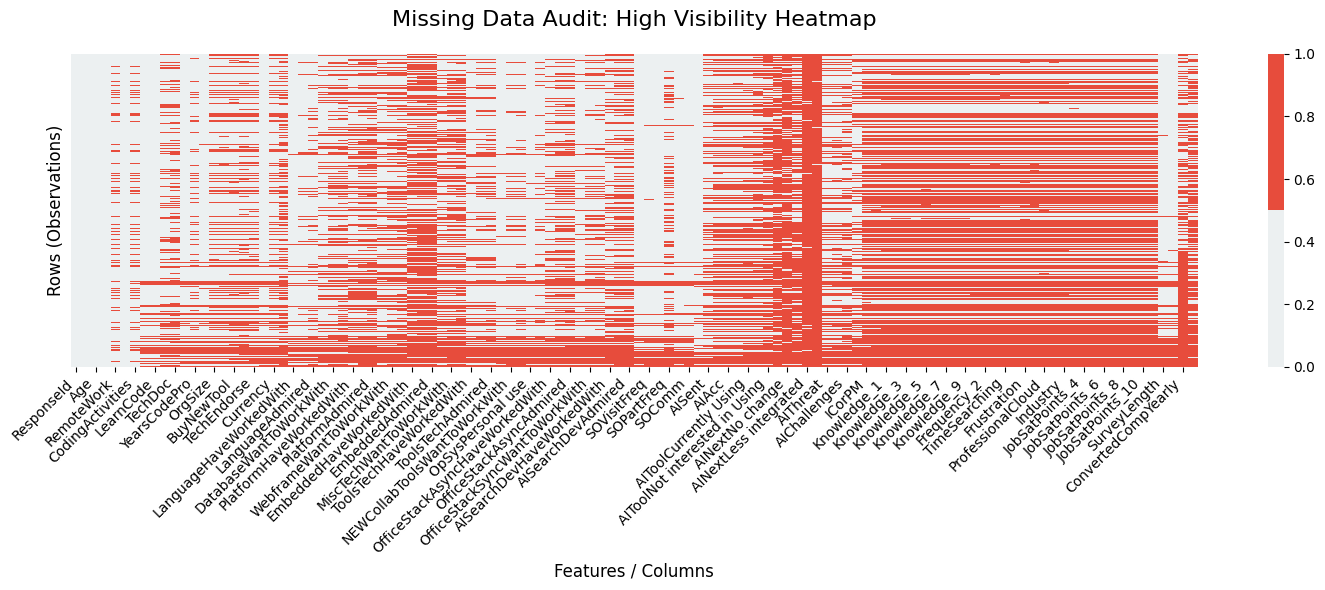

In [9]:

# 1. Set the figure size to be wider to see columns clearly
plt.figure(figsize=(15, 6))

# 2. Use a custom high-contrast color palette
# Red (#E74C3C) for Missing Values, Light Grey (#ECF0F1) for existing data
colors = ["#ECF0F1", "#E74C3C"] 
sns.heatmap(df.isnull(), 
            yticklabels=False, 
            cmap=sns.color_palette(colors), 
            cbar=True)

# 3. Add descriptive labels and title
plt.title('Missing Data Audit: High Visibility Heatmap', fontsize=16, pad=20)
plt.xlabel('Features / Columns', fontsize=12)
plt.ylabel('Rows (Observations)', fontsize=12)

# Rotate x-labels if they are crowded
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('improved_missing_values_heatmap.png')

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [20]:
## Write your code here
# Identify and count missing values in the 'Employment' column
missing_employment = df['Employment'].isnull().sum()

# Display the result
print(f"Number of missing values in 'Employment' column: {missing_employment}")

Number of missing values in 'Employment' column: 0


### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [10]:
## Write your code here
# Identify and count missing values in the 'Employment' column
missing_employment = df['Employment'].isnull().sum()

# Display the result
print(f"Number of missing values in 'Employment' column: {missing_employment}")

Number of missing values in 'Employment' column: 0


##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [11]:
## Write your code here
# 1. Identify the most frequent value (Mode) in the 'Employment' column
# .mode() returns a Series, so we take the first element [0], mode() method finds the most common value in the column.
employment_mode = df['Employment'].mode()[0]
print(f"The most frequent value (Mode) is: {employment_mode}")

# 2. Impute (fill) missing values with the Mode
df['Employment'] = df['Employment'].fillna(employment_mode)

# 3. Verify that there are no more missing values in that column
print(f"Remaining missing values in 'Employment': {df['Employment'].isnull().sum()}")

#The reason we “impute” missing values rather than “deleting” them is to preserve the sample size. 
#However, the imputed data is, after all, merely an “estimate.” 
#If missing values exceed 30% of the total, it may be necessary to create a new category labeled “unknown” or exclude that variable from the analysis altogether, rather than forcing an imputation.


The most frequent value (Mode) is: Employed, full-time
Remaining missing values in 'Employment': 0


### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


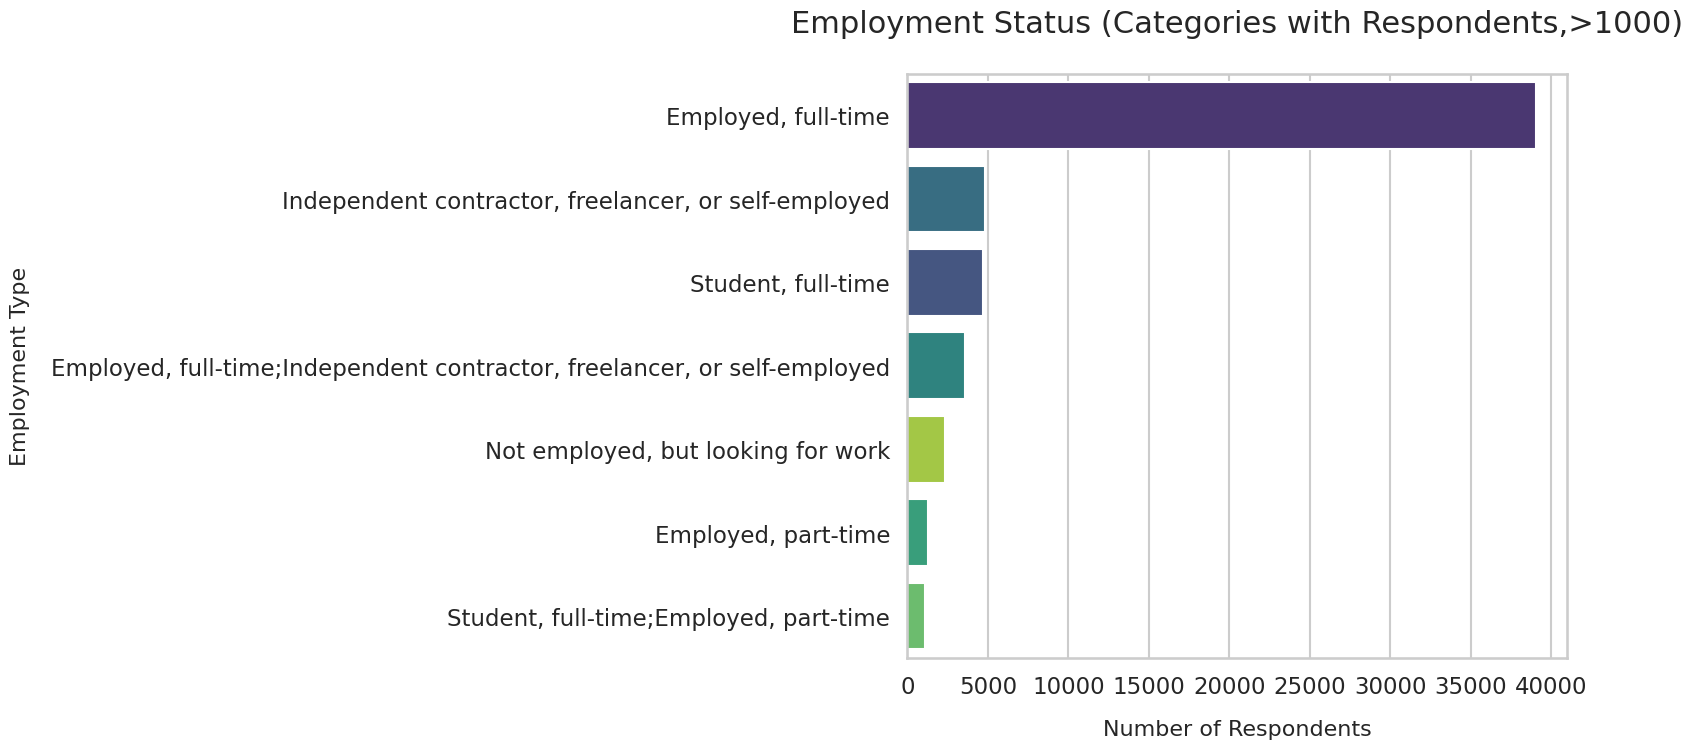

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate counts and filter out those with 0 (or a small threshold)
employment_counts = df['Employment'].value_counts()
# Filter: Keep only categories where respondents > 1000
meaningful_categories = employment_counts[employment_counts > 1000].index

# 2. Filter the dataframe to only include these categories
df_filtered = df[df['Employment'].isin(meaningful_categories)]

# 3. Visualization
sns.set_theme(style="whitegrid")
sns.set_context("talk")
plt.figure(figsize=(12, 8))

sns.countplot(
    data=df_filtered, 
    y='Employment', 
    hue='Employment', 
    palette='viridis', 
    legend=False,
    order=meaningful_categories # Sorted by frequency
)

plt.title('Employment Status (Categories with Respondents,>1000)', fontsize=22, pad=30)
plt.xlabel('Number of Respondents', fontsize=16, labelpad=15)
plt.ylabel('Employment Type', fontsize=16, labelpad=15)

plt.subplots_adjust(left=0.35, bottom=0.15)
plt.show()

In [19]:
#Calculating Large Employment Segment Impact
# 1. Get the counts for each employment type
employment_counts = df['Employment'].value_counts()

# 2. Filter for types with more than 1000 respondents
large_segments = employment_counts[employment_counts > 1000]

# 3. Calculate the sum of respondents in these large segments
total_large_segments = large_segments.sum()

# 4. Calculate the percentage relative to the whole dataset
total_respondents = len(df) # Or use df['Employment'].count() for non-null total
percentage = (total_large_segments / total_respondents) * 100

print(f"Employment types with >1000 respondents:")
print(large_segments)
print(f"\nTotal respondents in these types: {total_large_segments}")
print(f"Percentage of total data: {percentage:.2f}%")

Employment types with >1000 respondents:
Employment
Employed, full-time                                                         39046
Independent contractor, freelancer, or self-employed                         4847
Student, full-time                                                           4712
Employed, full-time;Independent contractor, freelancer, or self-employed     3557
Not employed, but looking for work                                           2341
Employed, part-time                                                          1266
Student, full-time;Employed, part-time                                       1115
Name: count, dtype: int64

Total respondents in these types: 56884
Percentage of total data: 86.92%


### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
